### Imports

In [1]:
import statistics
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import torchaudio
from IPython.lib.display import Audio
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from src.config import CONFIG
from src.preprocessing import get_waveform_transformer, get_spectrogram_transformer

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [2]:
INPUT_DIR = Path('../../data/BatvisionV2')

### Profiling the BatVision dataset

In [3]:
def run_profiling() -> None:
    durations = []
    sample_rates = Counter()
    channels = Counter()

    for audio_file in INPUT_DIR.rglob("*.wav"):
        info = torchaudio.info(audio_file)
        sample_rates[info.sample_rate] += 1
        channels[info.num_channels] += 1
        durations.append(info.num_frames / info.sample_rate)

    print(f'Number of files: {len(durations)}')
    print(f'Sample rates: {dict(sample_rates)}')
    print(f'Channels: {dict(channels)}')
    print()
    print('[Durations]')
    print(f'Min: {min(durations):.3f}s')
    print(f'Max: {max(durations):.3f}s')
    print(f'Mean: {sum(durations)/len(durations):.3f}s')
    print(f'Median: {statistics.median(durations):.3f}s')

run_profiling()

Number of files: 3120
Sample rates: {44100: 3120}
Channels: {2: 3120}

[Durations]
Min: 0.453s
Max: 0.454s
Mean: 0.454s
Median: 0.454s


### Visualising BatVision audio as Gammatone Spectrograms

STFT kernels created, time used = 0.0127 seconds
STFT filter created, time used = 0.0053 seconds
Gammatone filter created, time used = 0.0053 seconds
torch.Size([2, 128, 40])


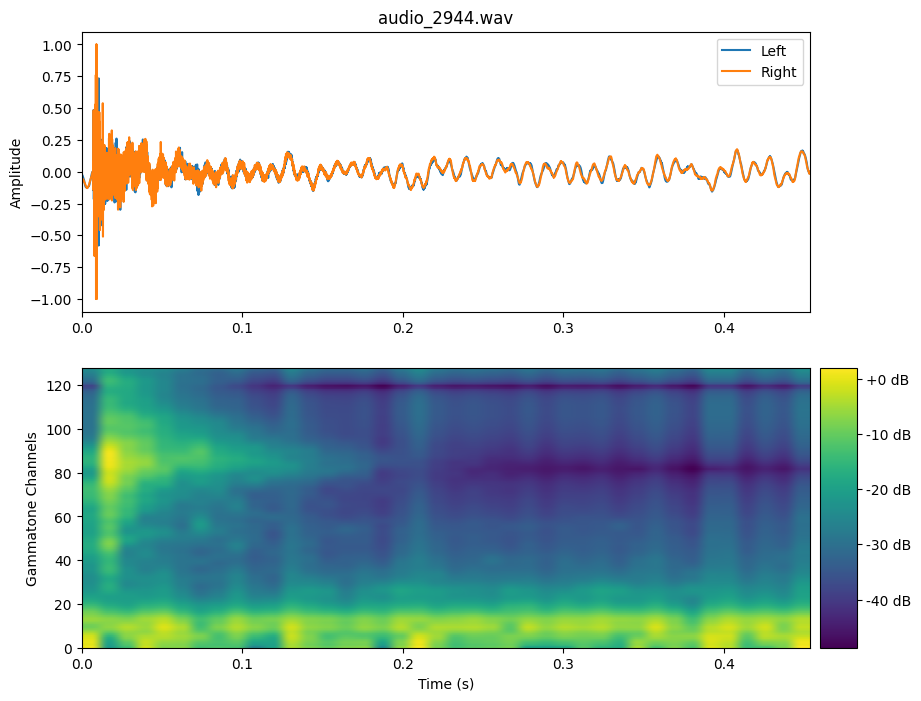

Original: 20000 samples (0.45s)
Preprocessed: 20021 samples (0.45s)
torch.Size([2, 128, 40])


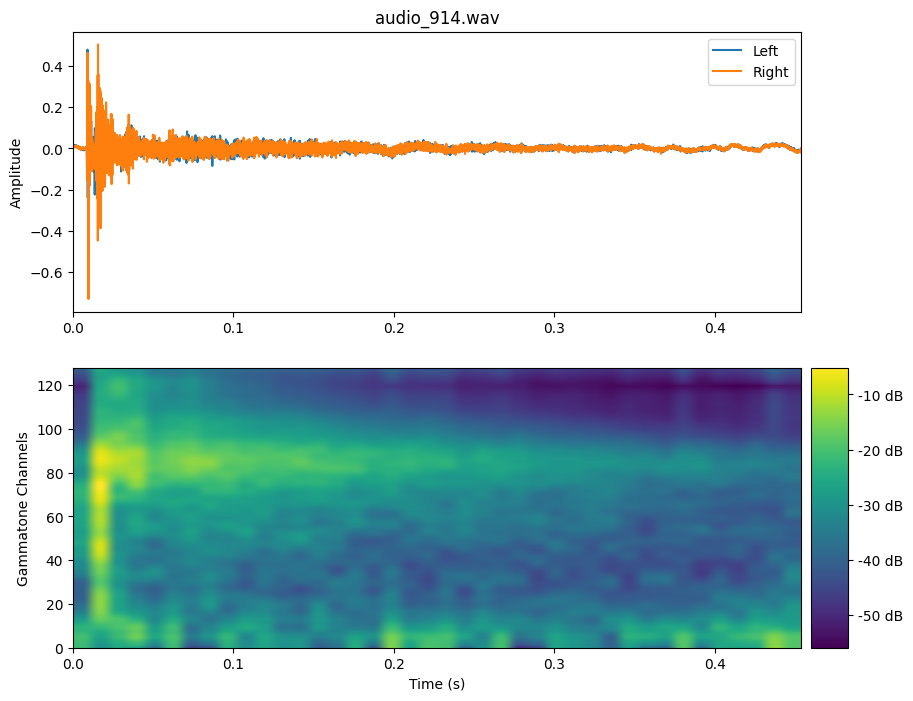

Original: 20000 samples (0.45s)
Preprocessed: 20021 samples (0.45s)
torch.Size([2, 128, 40])


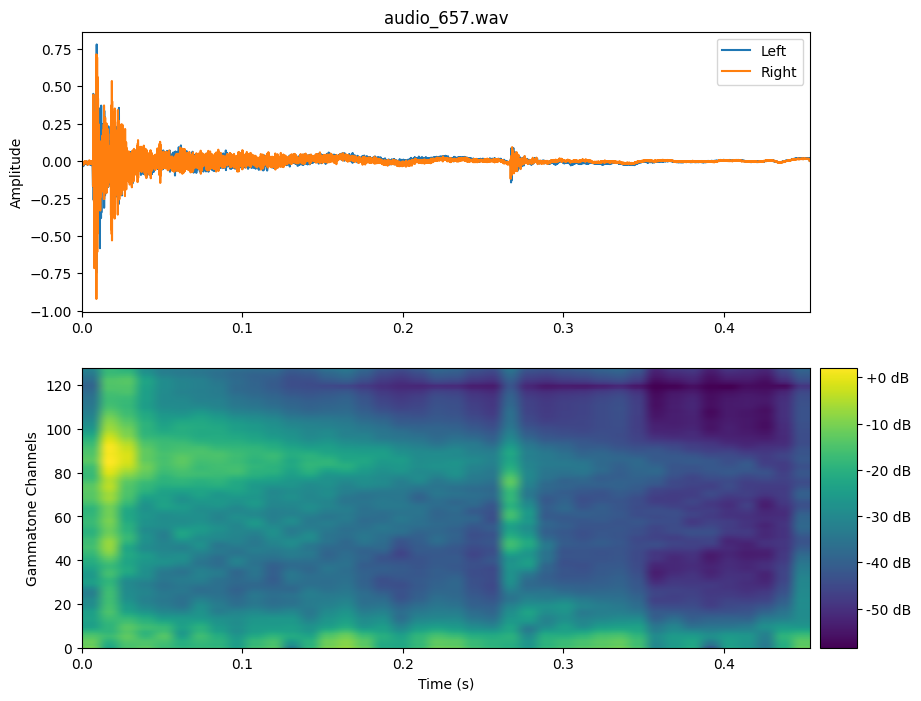

Original: 19999 samples (0.45s)
Preprocessed: 20021 samples (0.45s)


In [4]:
def get_random_audio(dir: Path) -> Path:
    audio_files = list(dir.rglob('*.wav'))
    return audio_files[np.random.randint(0, len(audio_files))]

def visualise_audio_data() -> None:
    config = CONFIG.batvision
    waveform_transformer = get_waveform_transformer(config)
    spectrogram_transformer = get_spectrogram_transformer(config, filterbank='gammatone')

    for i in range(3):
        file = get_random_audio(INPUT_DIR)

        raw_waveform, raw_sample_rate = torchaudio.load(file, normalize=True)
        new_waveform = waveform_transformer(raw_waveform)
        gammatone_spectrogram = spectrogram_transformer(new_waveform)
        print(gammatone_spectrogram.shape)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / config.target_sample_rate

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

        # Waveform
        time_axis = np.linspace(0, new_duration, new_samples)
        ax1.plot(time_axis, new_waveform[0].numpy(), label='Left')
        ax1.plot(time_axis, new_waveform[1].numpy(), label='Right')
        ax1.set_title(file.name)
        ax1.set_xlim(0, new_duration)
        ax1.set_ylabel('Amplitude')
        ax1.legend()

        # Placeholder to allow the two graphs to align
        div1 = make_axes_locatable(ax1)
        cax1 = div1.append_axes("right", size="5%", pad=0.1)
        cax1.axis("off")

        # Gammatone Spectrogram
        img = ax2.imshow(
            gammatone_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='viridis',
            extent=[0, new_duration, 0, config.n_bins],
        )
        ax2.set_ylabel('Gammatone Channels')
        ax2.set_xlabel('Time (s)')

        div2 = make_axes_locatable(ax2)
        cax2 = div2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(img, cax=cax2, format='%+2.0f dB')

        plt.show()

        display(Audio(data=new_waveform, rate=config.target_sample_rate))
        print(f'Original: {raw_waveform.shape[1]} samples ({raw_waveform.shape[1]/raw_sample_rate:.2f}s)')
        print(f'Preprocessed: {new_samples} samples ({new_duration:.2f}s)')

visualise_audio_data()